# Final Project: Credit Card Fraud Detection System
**Dataset:** Credit Card Fraud Detection (Kaggle)  
**Problem:** Detect fraudulent transactions from highly imbalanced real bank data  
**Models:** Logistic Regression, Decision Tree, Random Forest  
**Evaluation:** Confusion Matrix, Precision, Recall, F1, ROC-AUC

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import joblib
import warnings
warnings.filterwarnings('ignore')

In [4]:
import pandas as pd 
df = pd.read_csv(r'D:\Projects\Credit card fraud detection\creditcard.csv\creditcard.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 1: Exploratory Data Analysis (EDA)

In [5]:
print("=== Dataset Info ===")
df.info()

print("\n=== Statistical Summary ===")
print(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum().sum(), "missing values found")

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  

In [6]:
fraud_count = df['Class'].value_counts()
print("Class Distribution:")
print(f"Legitimate Transactions (0): {fraud_count[0]}")
print(f"Fraudulent Transactions (1): {fraud_count[1]}")
print(f"\nFraud Percentage: {fraud_count[1]/len(df)*100:.4f}%")

Class Distribution:
Legitimate Transactions (0): 284315
Fraudulent Transactions (1): 492

Fraud Percentage: 0.1727%


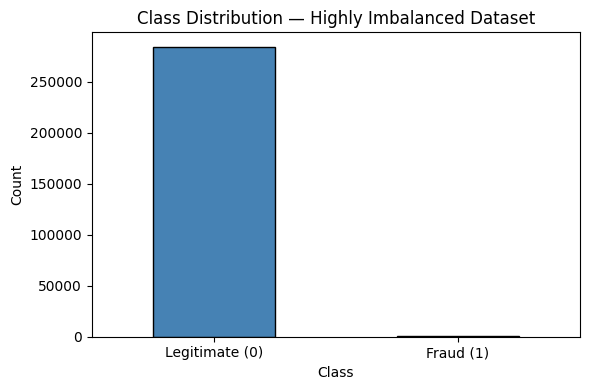

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
fraud_count.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.xticks([0, 1], ['Legitimate (0)', 'Fraud (1)'], rotation=0)
plt.title('Class Distribution — Highly Imbalanced Dataset')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

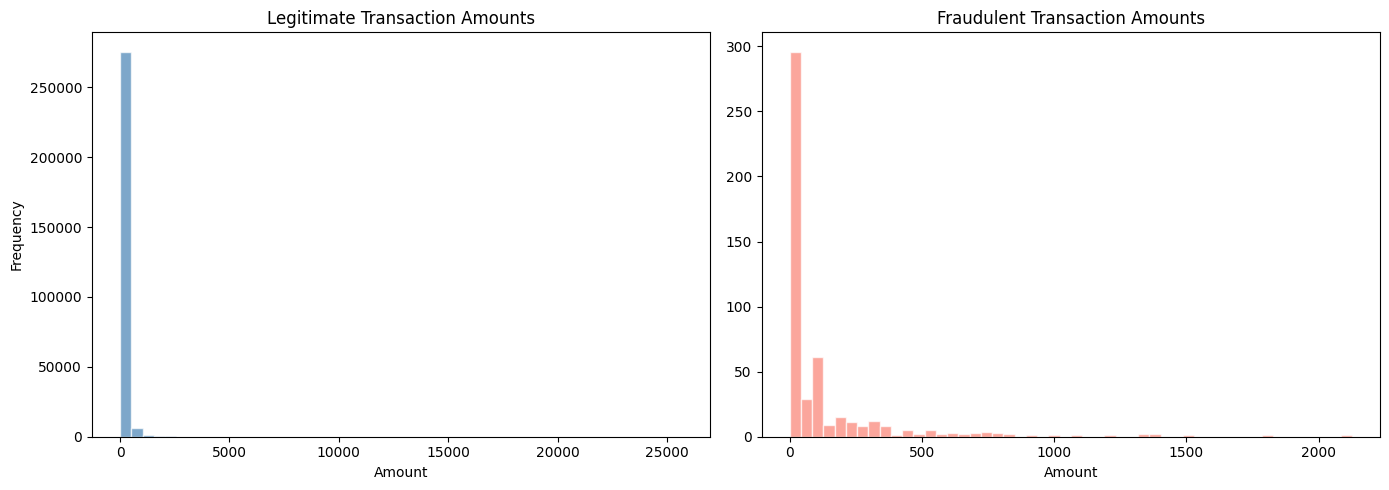

Average Legitimate Amount: $88.29
Average Fraudulent Amount: $122.21


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['Class']==0]['Amount'], bins=50,
             color='steelblue', edgecolor='white', alpha=0.7)
axes[0].set_title('Legitimate Transaction Amounts')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

axes[1].hist(df[df['Class']==1]['Amount'], bins=50,
             color='salmon', edgecolor='white', alpha=0.7)
axes[1].set_title('Fraudulent Transaction Amounts')
axes[1].set_xlabel('Amount')

plt.tight_layout()
plt.savefig('transaction_amounts.png')
plt.show()

print(f"Average Legitimate Amount: ${df[df['Class']==0]['Amount'].mean():.2f}")
print(f"Average Fraudulent Amount: ${df[df['Class']==1]['Amount'].mean():.2f}")

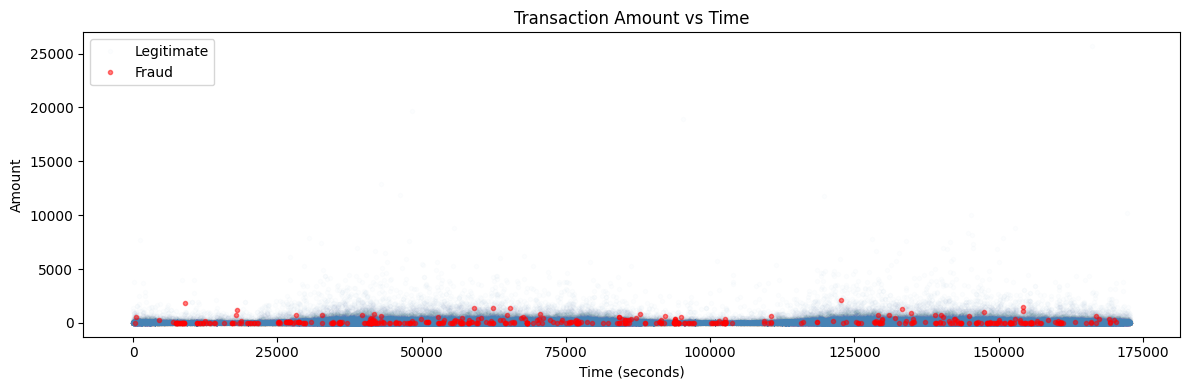

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(df[df['Class']==0]['Time'], df[df['Class']==0]['Amount'],
         '.', alpha=0.01, color='steelblue', label='Legitimate')
plt.plot(df[df['Class']==1]['Time'], df[df['Class']==1]['Amount'],
         '.', alpha=0.5, color='red', label='Fraud')
plt.title('Transaction Amount vs Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Amount')
plt.legend()
plt.tight_layout()
plt.savefig('time_vs_amount.png')
plt.show()

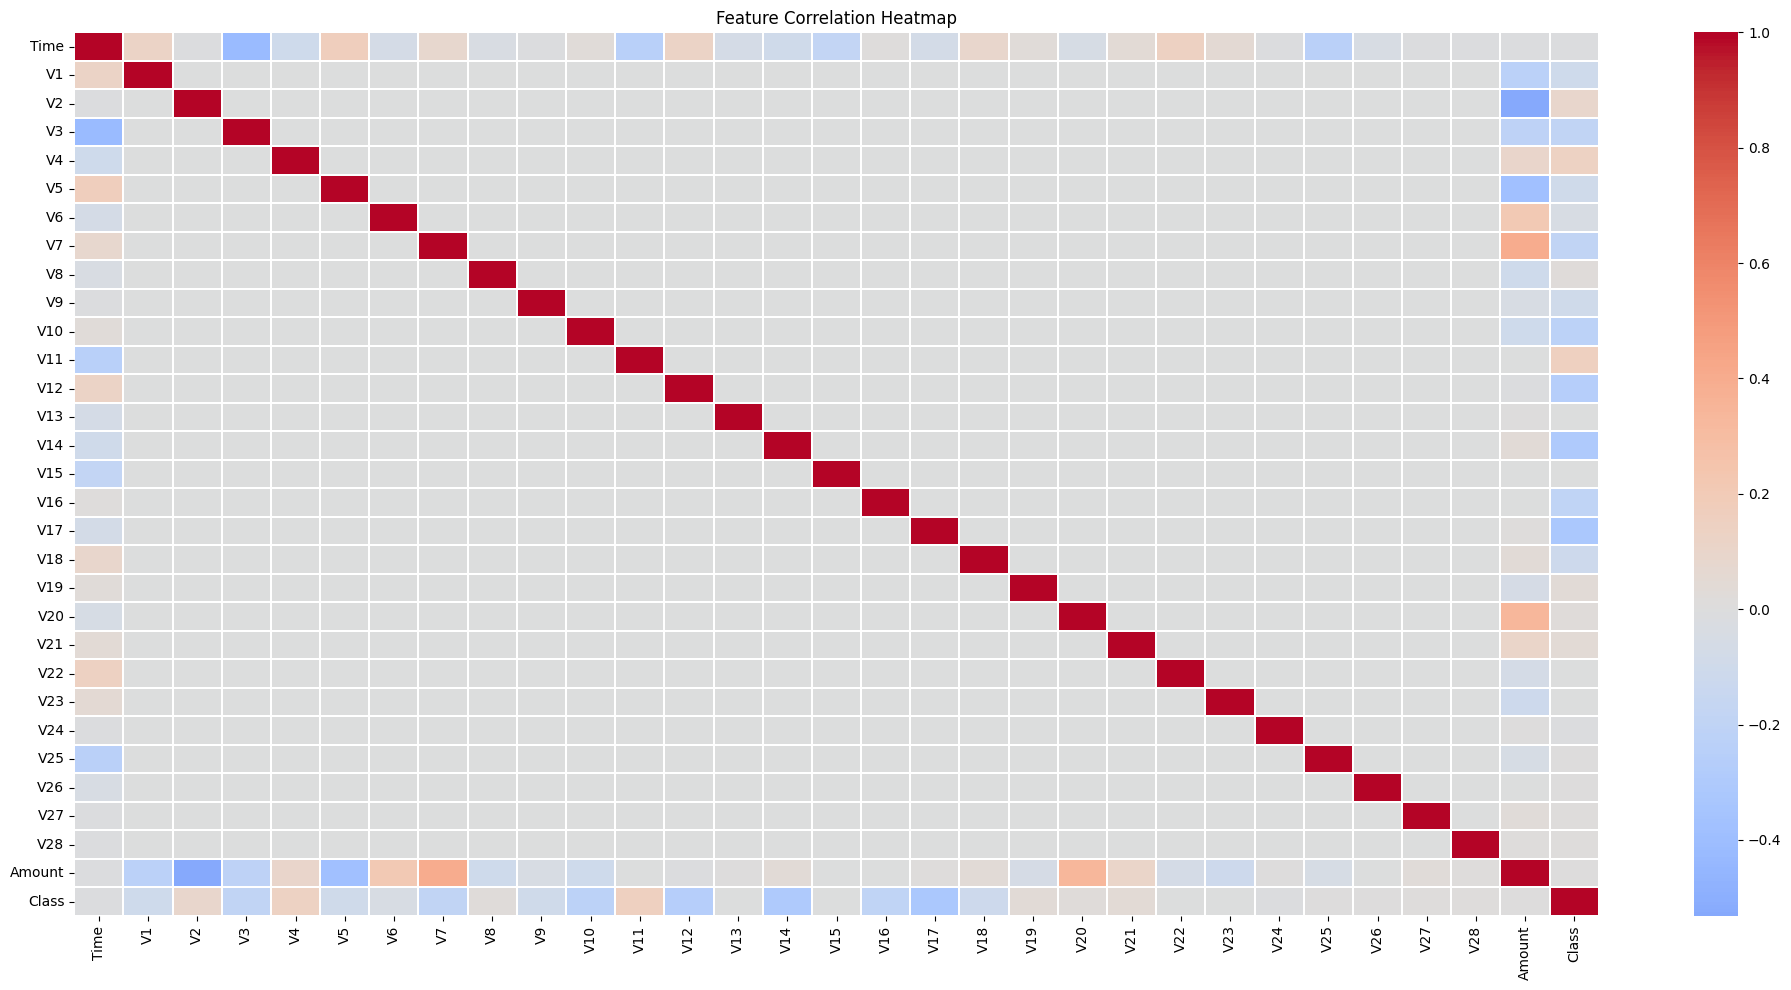

In [12]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0, linewidths=0.1)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

## Step 2: Data Preprocessing

In [13]:
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])

df = df.drop(columns=['Amount', 'Time'])
print("Amount and Time scaled successfully")
print("New shape:", df.shape)

Amount and Time scaled successfully
New shape: (284807, 31)


In [14]:
X = df.drop(columns=['Class'])
y = df['Class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples:   {X_train.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")
print(f"\nTraining fraud cases:  {y_train.sum()}")
print(f"Testing fraud cases:   {y_test.sum()}")

Training samples:   227845
Testing samples:    56962

Training fraud cases:  394
Testing fraud cases:   98


## Step 3: Train Models & Detect Overfitting
Training 3 models and checking for overfitting by comparing Train vs Test performance.

In [17]:
models = {
    "Logistic Regression":  LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1),
    "Decision Tree":        DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=10),
    "Random Forest":        RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=50, max_depth=12, n_jobs=-1)
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully!")

Logistic Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!


In [18]:
print("=== Train vs Test F1 Score (Overfitting Check) ===\n")

for name, model in trained_models.items():
    train_f1 = f1_score(y_train, model.predict(X_train))
    test_f1  = f1_score(y_test,  model.predict(X_test))
    gap      = train_f1 - test_f1
    print(f"{name}")
    print(f"  Train F1: {train_f1:.4f}  |  Test F1: {test_f1:.4f}  |  Gap: {gap:.4f}")
    if gap > 0.1:
        print(f"  ⚠️  Possible overfitting detected")
    else:
        print(f"  ✅  No significant overfitting")
    print()

=== Train vs Test F1 Score (Overfitting Check) ===

Logistic Regression
  Train F1: 0.1182  |  Test F1: 0.1141  |  Gap: 0.0040
  ✅  No significant overfitting

Decision Tree
  Train F1: 0.3132  |  Test F1: 0.2258  |  Gap: 0.0874
  ✅  No significant overfitting

Random Forest
  Train F1: 0.9173  |  Test F1: 0.7714  |  Gap: 0.1459
  ⚠️  Possible overfitting detected



## Step 4: Cross-Validation

In [19]:
print("=== 5-Fold Cross-Validation F1 Scores ===\n")

for name, model in trained_models.items():
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='f1')
    print(f"{name}")
    print(f"  CV F1 Scores: {cv_scores.round(4)}")
    print(f"  Mean F1:      {cv_scores.mean():.4f}")
    print(f"  Std Dev:      {cv_scores.std():.4f}")
    print()

=== 5-Fold Cross-Validation F1 Scores ===

Logistic Regression
  CV F1 Scores: [0.0405 0.1675 0.0805 0.0853 0.1979]
  Mean F1:      0.1143
  Std Dev:      0.0587

Decision Tree
  CV F1 Scores: [0.0034 0.164  0.2181 0.2375 0.    ]
  Mean F1:      0.1246
  Std Dev:      0.1032

Random Forest
  CV F1 Scores: [0.2689 0.9022 0.7041 0.8103 0.7927]
  Mean F1:      0.6956
  Std Dev:      0.2224



## Step 5: Hyperparameter Tuning with GridSearchCV
Tuning the Random Forest for best performance.

In [ ]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth':    [10, 20],
    'min_samples_split': [2, 5]
}

# Reduce the search space and folds to keep tuning fast for large datasets.
grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    scoring='f1',
    cv=2,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(f"\nBest Parameters: {grid.best_params_}")
print(f"Best CV F1 Score: {grid.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1 Score: 0.8436


## Step 6: Evaluate All Models

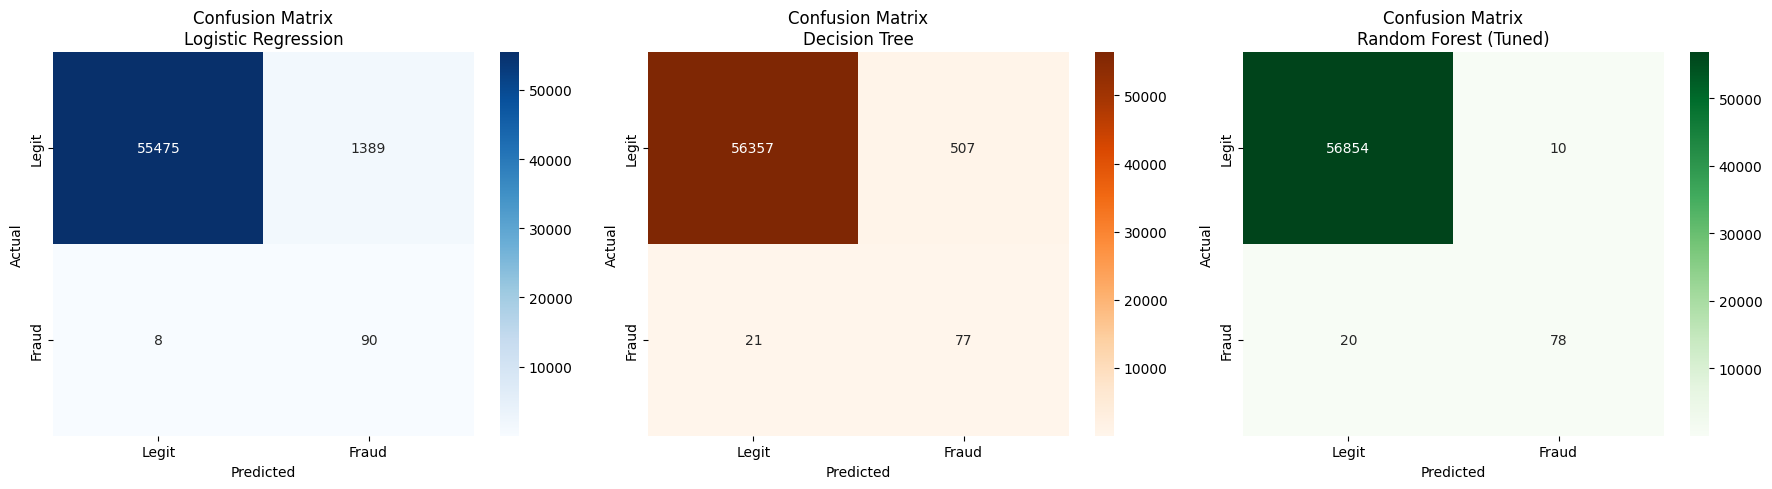

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_list = {
    "Logistic Regression": trained_models["Logistic Regression"],
    "Decision Tree":       trained_models["Decision Tree"],
    "Random Forest (Tuned)": grid.best_estimator_
}

colors = ['Blues', 'Oranges', 'Greens']

for ax, (name, model), color in zip(axes, model_list.items(), colors):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=ax,
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'])
    ax.set_title(f'Confusion Matrix\n{name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

In [22]:
for name, model in model_list.items():
    y_pred = model.predict(X_test)
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred,
          target_names=['Legitimate', 'Fraud']))
    print()

=== Logistic Regression ===
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962


=== Decision Tree ===
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     56864
       Fraud       0.13      0.79      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.89      0.61     56962
weighted avg       1.00      0.99      0.99     56962


=== Random Forest (Tuned) ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.89      0.80      0.84        98

    accuracy                           1.00     56962
   macro avg       0.94      0.90      0.92   

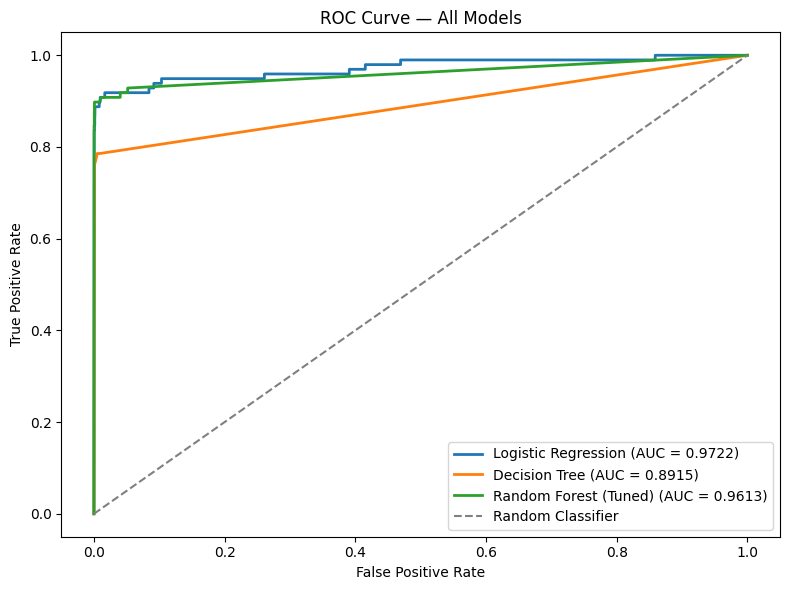

In [23]:
plt.figure(figsize=(8, 6))

for name, model in model_list.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curves.png')
plt.show()

In [24]:
def get_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred), 4),
        "F1 Score":  round(f1_score(y_test, y_pred), 4),
        "AUC":       round(roc_auc_score(y_test, y_prob), 4)
    }

results = {name: get_metrics(model, X_test, y_test)
           for name, model in model_list.items()}

results_df = pd.DataFrame(results).T
print(results_df)
results_df.style.highlight_max(color='lightgreen', axis=0)

                       Accuracy  Precision  Recall  F1 Score     AUC
Logistic Regression      0.9755     0.0609  0.9184    0.1141  0.9722
Decision Tree            0.9907     0.1318  0.7857    0.2258  0.8915
Random Forest (Tuned)    0.9995     0.8864  0.7959    0.8387  0.9613


,Accuracy,Precision,Recall,F1 Score,AUC
Logistic Regression,0.975500,0.060900,0.918400,0.114100,0.972200
Decision Tree,0.990700,0.131800,0.785700,0.225800,0.891500
Random Forest (Tuned),0.999500,0.886400,0.795900,0.838700,0.961300


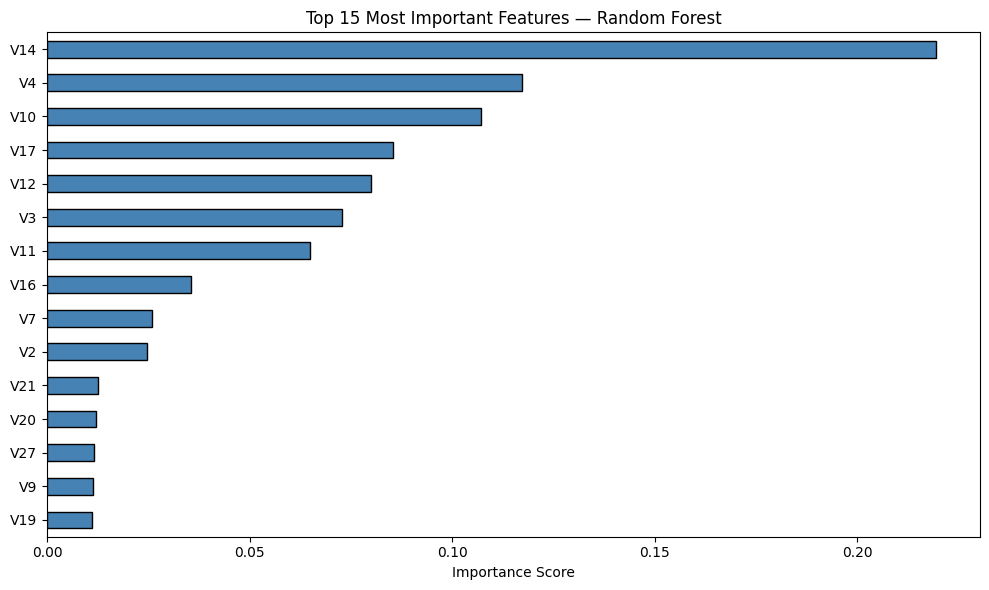

In [25]:
best_rf = grid.best_estimator_
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
top_features = importances.nlargest(15)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Most Important Features — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [26]:
best_model_name = results_df['F1 Score'].idxmax()
best_metrics    = results_df.loc[best_model_name]

print(f"Selected Model: {best_model_name}")
print(f"F1 Score:       {best_metrics['F1 Score']}")
print(f"Recall:         {best_metrics['Recall']}")
print(f"AUC:            {best_metrics['AUC']}")
print("""
Justification:
- In fraud detection, Recall is the most critical metric.
  Missing a fraud (False Negative) causes direct financial loss.
- F1 Score balances Precision and Recall — best for imbalanced datasets.
- AUC measures discrimination ability across all classification thresholds.
- class_weight='balanced' was used to handle the extreme class imbalance.
- GridSearchCV found the optimal hyperparameters for the Random Forest.
- The selected model achieves the best balance of F1 and Recall.
""")

Selected Model: Random Forest (Tuned)
F1 Score:       0.8387
Recall:         0.7959
AUC:            0.9613

Justification:
- In fraud detection, Recall is the most critical metric.
  Missing a fraud (False Negative) causes direct financial loss.
- F1 Score balances Precision and Recall — best for imbalanced datasets.
- AUC measures discrimination ability across all classification thresholds.
- class_weight='balanced' was used to handle the extreme class imbalance.
- GridSearchCV found the optimal hyperparameters for the Random Forest.
- The selected model achieves the best balance of F1 and Recall.



In [27]:
joblib.dump(best_rf, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Best model saved as best_model.pkl")
print("Scaler saved as scaler.pkl")

Best model saved as best_model.pkl
Scaler saved as scaler.pkl


## Conclusion
- Credit card fraud detection is an extreme class imbalance problem (only ~0.17% fraud).
- Accuracy is completely misleading here — a model predicting all legitimate gets 99.8% accuracy.
- Recall and F1-Score are the correct metrics for fraud detection.
- class_weight='balanced' effectively handles imbalance without losing data.
- Random Forest with tuned hyperparameters outperforms simpler models.
- Feature importance analysis reveals which transaction patterns indicate fraud.
- Next steps: Try SMOTE oversampling, XGBoost, or anomaly detection approaches.